# RoPE debug: noisy video / identity image / expression video

Ce notebook visualise les positions RoPE dans un cube `time x height x width`.

Il suit le meme chemin que la pipeline au niveau qui nous interesse:
`image/video -> VAE latents -> DiT patchify -> DualConditionBuilder -> condition_freqs_from_geometry`.

Par defaut, `LOAD_REAL_PIPELINE = False` pour permettre de verifier la geometrie sans charger Wan. Mets-le a `True` et renseigne les chemins pour passer par la vraie pipeline.

In [1]:
from pathlib import Path

# --- inputs ---
IDENTITY_IMAGE_PATH = "/home/ens.old/Bpokrzywa/datasets/MEAD_neutral_frames/W036/left_60/neutral_frames.png"      
EXPRESSION_VIDEO_PATH = "/home/ens.old/Bpokrzywa/datasets/MEAD_full/MEAD/W036/video/left_60/disgusted/level_1/051.mp4"    
WAN_MODEL_PATH = "checkpoints/Wan2.1/t2v"

# --- run mode ---
LOAD_REAL_PIPELINE = True
USE_FACE_DETECTION = True    # only used when LOAD_REAL_PIPELINE=True
DEVICE = "cuda"
DTYPE_NAME = "bf16"           # bf16 / fp16 / fp32
VAE_TILED = True              # safer for the real-pipeline probe
VAE_TILE_SIZE = (30, 52)
VAE_TILE_STRIDE = (15, 26)

# --- generation geometry, should match train/infer ---
HEIGHT = 384
WIDTH = 640
NUM_FRAMES = 81
EXPRESSION_FRAMES = 65
MAX_EXPRESSION_TOKENS = 8192

# Normalized box [x1, y1, x2, y2]. Used if you do not run face detection.
EXPRESSION_FACE_BOX = [0.25, 0.12, 0.75, 0.82]

REPO_ROOT = Path.cwd()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parents[1]
elif (REPO_ROOT / "expression_identity_gen").exists():
    REPO_ROOT = REPO_ROOT
else:
    raise RuntimeError(f"Run this notebook from the repo root or notebooks dir, got {REPO_ROOT}")

WAN_CODE_ROOT = REPO_ROOT / "expression_identity_gen"
WAN_CODE_ROOT

PosixPath('/home/ens.old/Bpokrzywa/expression_identity_gen')

In [2]:
from IPython.display import Video, display

video_path = "/home/ens.old/Bpokrzywa/datasets/MEAD_full/MEAD/W036/video/left_60/disgusted/level_1/051.mp4"
display(Video(video_path, embed=True, width=640))

In [3]:
import os
import sys
from dataclasses import dataclass
from types import SimpleNamespace

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image

sys.path.insert(0, str(WAN_CODE_ROOT))

from models.expression_adapter import ExpressionAdapter
from models.rope_utils import condition_freqs_from_geometry, video_freqs
from models.wan_video_dit import precompute_freqs_cis_3d

def dtype_from_name(name):
    return {"bf16": torch.bfloat16, "bfloat16": torch.bfloat16, "fp16": torch.float16, "float16": torch.float16, "fp32": torch.float32, "float32": torch.float32}[name]

def load_image(path):
    return Image.open(path).convert("RGB")

def load_video_frames(path, count):
    import imageio
    reader = imageio.get_reader(path)
    total = reader.count_frames()
    ids = np.linspace(0, max(total - 1, 0), count).round().astype(int)
    frames = [Image.fromarray(reader.get_data(int(i))).convert("RGB") for i in ids]
    reader.close()
    return frames

@dataclass
class DebugDit:
    dim: int = 5120
    num_heads: int = 40
    patch_size: tuple = (1, 2, 2)

    def __post_init__(self):
        self.freqs = precompute_freqs_cis_3d(self.dim // self.num_heads)

    def patchify(self, latents):
        b, c, f, h, w = latents.shape
        pf, ph, pw = self.patch_size
        grid = (f // pf, h // ph, w // pw)
        tokens = torch.zeros((b, grid[0] * grid[1] * grid[2], self.dim), device=latents.device, dtype=latents.dtype)
        return tokens, grid

def latent_shape_from_pixels(height, width, frames):
    latent_f = (frames - 1) // 4 + 1
    latent_h = height // 8
    latent_w = width // 8
    return (1, 16, latent_f, latent_h, latent_w)

def grid_from_latents(dit, latents):
    _, _, frames, height, width = latents.shape
    pf, ph, pw = dit.patch_size
    return (frames // pf, height // ph, width // pw)

def print_cuda_mem(label):
    if torch.cuda.is_available() and str(device).startswith("cuda"):
        torch.cuda.synchronize(device)
        allocated = torch.cuda.memory_allocated(device) / 1024**3
        reserved = torch.cuda.memory_reserved(device) / 1024**3
        print(f"{label}: allocated={allocated:.2f}GB reserved={reserved:.2f}GB")

## Run pipeline probe

En mode reel, cette cellule charge Wan en CPU-first, encode l'image identity et la video expression avec le VAE, puis ne garde que les grilles et indices necessaires a RoPE. Elle evite volontairement de materialiser les gros tenseurs de tokens `[B, N, D]`, qui ne sont pas necessaires pour visualiser la geometrie et peuvent provoquer un CUDA OOM.

In [10]:
device = torch.device(DEVICE if torch.cuda.is_available() and DEVICE.startswith("cuda") else "cpu")
dtype = dtype_from_name(DTYPE_NAME)

if LOAD_REAL_PIPELINE:
    from pipelines.wan_video import ModelConfig, WanVideoPipeline

    if not IDENTITY_IMAGE_PATH or not EXPRESSION_VIDEO_PATH:
        raise ValueError("Set IDENTITY_IMAGE_PATH and EXPRESSION_VIDEO_PATH before LOAD_REAL_PIPELINE=True")

    base = Path(WAN_MODEL_PATH).expanduser()
    if not base.is_absolute():
        base = WAN_CODE_ROOT / base
    shard_count = 6
    diffusion_paths = [str(base / f"diffusion_pytorch_model-0000{i}-of-0000{shard_count}.safetensors") for i in range(1, shard_count + 1)]
    model_configs = [
        ModelConfig(path=diffusion_paths, offload_device="cpu", skip_download=True),
        ModelConfig(path=str(base / "Wan2.1_VAE.pth"), offload_device="cpu", skip_download=True),
    ]
    pipe = WanVideoPipeline.from_pretrained(
        torch_dtype=dtype,
        device=str(device),
        model_configs=model_configs,
        tokenizer_config=ModelConfig(path=str(base / "google/umt5-xxl"), offload_device="cpu", skip_download=True),
    )
    dit = pipe.dit
    identity_image = load_image(IDENTITY_IMAGE_PATH)
    identity_image = identity_image.resize((WIDTH, HEIGHT))
    expression_frames = load_video_frames(EXPRESSION_VIDEO_PATH, EXPRESSION_FRAMES)
    print_cuda_mem("after CPU-first pipeline load")
    pipe.vae.to(device)
    with torch.inference_mode():
        identity_tensor = torch.tensor(np.array(identity_image)).permute(2, 0, 1).float() / 255.0
        identity_tensor = identity_tensor.unsqueeze(1).unsqueeze(0).to(dtype=dtype)
        identity_tensor = identity_tensor * 2 - 1
        identity_latents = pipe.vae.encode(
            identity_tensor,
            device=str(device),
            tiled=VAE_TILED,
            tile_size=VAE_TILE_SIZE,
            tile_stride=VAE_TILE_STRIDE,
        )
        resized_expression_frames = [frame.resize((WIDTH, HEIGHT)) for frame in expression_frames]
        expression_video = pipe.preprocess_video(resized_expression_frames)
        expression_latents = pipe.vae.encode(
            expression_video,
            device=str(device),
            tiled=VAE_TILED,
            tile_size=VAE_TILE_SIZE,
            tile_stride=VAE_TILE_STRIDE,
        )
        del identity_tensor, resized_expression_frames, expression_video
    identity_grid = grid_from_latents(dit, identity_latents)
    expression_grid = grid_from_latents(dit, expression_latents)
    pipe.vae.cpu()
    identity_latents = identity_latents.cpu()
    expression_latents = expression_latents.cpu()
    if torch.cuda.is_available() and str(device).startswith("cuda"):
        torch.cuda.empty_cache()
    print_cuda_mem("after VAE encode + offload")
else:
    pipe = None
    dit = DebugDit()
    identity_latents = torch.zeros(latent_shape_from_pixels(HEIGHT, WIDTH, 1), device=device, dtype=dtype)
    expression_latents = torch.zeros(latent_shape_from_pixels(HEIGHT, WIDTH, EXPRESSION_FRAMES), device=device, dtype=dtype)
    identity_grid = grid_from_latents(dit, identity_latents)
    expression_grid = grid_from_latents(dit, expression_latents)

main_grid = grid_from_latents(dit, torch.empty(latent_shape_from_pixels(HEIGHT, WIDTH, NUM_FRAMES)))
main_token_count = int(np.prod(main_grid))
if LOAD_REAL_PIPELINE and USE_FACE_DETECTION:
    expression_face_boxes = pipe.detect_expression_face_boxes(expression_frames)
    if expression_face_boxes is None:
        expression_face_boxes = torch.tensor(EXPRESSION_FACE_BOX, device=device, dtype=torch.float32)
        print("face detection failed; manual expression_face_boxes:", expression_face_boxes.tolist())
    else:
        expression_face_boxes = torch.tensor(expression_face_boxes, device=device, dtype=torch.float32)
        print("detected expression_face_boxes:", expression_face_boxes.shape)
else:
    expression_face_boxes = torch.tensor(EXPRESSION_FACE_BOX, device=device, dtype=torch.float32)
    print("manual expression_face_boxes:", expression_face_boxes.tolist())

expression_adapter = ExpressionAdapter(dim=dit.dim, max_expression_tokens=MAX_EXPRESSION_TOKENS).to(device)
expression_token_indices = expression_adapter.face_token_indices(
    batch_size=1,
    grid=expression_grid,
    device=device,
    face_boxes=expression_face_boxes,
)
condition = SimpleNamespace(
    identity_grid=identity_grid,
    expression_grid=expression_grid,
    expression_token_indices=expression_token_indices,
    identity_token_count=int(np.prod(identity_grid)),
    expression_token_count=expression_token_indices.shape[1],
)

main_freqs = video_freqs(dit, main_grid, device=device)
condition_freqs = condition_freqs_from_geometry(
    dit=dit,
    main_grid=main_grid,
    device=device,
    identity_grid=condition.identity_grid,
    expression_grid=condition.expression_grid,
    expression_token_indices=condition.expression_token_indices,
)

print("main_grid:", main_grid, "tokens:", main_token_count, "freqs:", tuple(main_freqs.shape))
print("identity_grid:", condition.identity_grid, "tokens:", condition.identity_token_count)
print("expression_grid:", condition.expression_grid, "tokens:", condition.expression_token_count)
print("condition_freqs:", tuple(condition_freqs.shape))

Loading models from: ['/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00001-of-00006.safetensors', '/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00002-of-00006.safetensors', '/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00003-of-00006.safetensors', '/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00004-of-00006.safetensors', '/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00005-of-00006.safetensors', '/home/ens.old/Bpokrzywa/expression_identity_gen/checkpoints/Wan2.1/t2v/diffusion_pytorch_model-00006-of-00006.safetensors']
    model_name: wan_video_dit model_class: WanModel
        This model is initialized with extra kwargs: {'has_image_input': False, 'patch_size': [1, 2, 2], 'in_dim': 16, 'dim': 5120, 'ffn_dim': 13824, 'freq_dim': 256, 'text_dim

VAE encoding: 100%|██████████| 9/9 [00:03<00:00,  2.80it/s]


after VAE encode + offload: allocated=0.11GB reserved=0.32GB
[wan-debug +   344.9s] Initializing InsightFace detector for expression boxes
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ens.old/Bpokrzywa/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ens.old/Bpokrzywa/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ens.old/Bpokrzywa/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ens.old/Bpokrzywa/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CP

/tmp/ipykernel_4162294/1356006656.py:76: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  expression_face_boxes = torch.tensor(expression_face_boxes, device=device, dtype=torch.float32)


## Convert RoPE layout to cube coordinates

Les coordonnees ci-dessous representent la position semantique utilisee par RoPE:

- noisy video: `t = 0..F-1`, `h = 1..`, `w = 1..`
- identity: `t = -1`, spatial grid preservee, placee au condition offset
- expression: `t = 0..F_expr-1`, spatial grid preservee, placee au meme condition offset que identity

In [11]:
def full_grid_coords(group, grid, h_start, w_start, time_mode):
    f, h, w = grid
    tt, yy, xx = torch.meshgrid(torch.arange(f), torch.arange(h), torch.arange(w), indexing="ij")
    if time_mode == "static_ref":
        rope_t = torch.full_like(tt, -1)
        freq_t_index = torch.zeros_like(tt)
    elif time_mode == "video":
        rope_t = tt
        freq_t_index = tt + 1
    else:
        raise ValueError(time_mode)
    return {
        "group": np.array([group] * tt.numel()),
        "t": rope_t.flatten().numpy(),
        "h": (yy + h_start).flatten().numpy(),
        "w": (xx + w_start).flatten().numpy(),
        "local_t": tt.flatten().numpy(),
        "local_h": yy.flatten().numpy(),
        "local_w": xx.flatten().numpy(),
        "freq_t_index": freq_t_index.flatten().numpy(),
        "flat_index": torch.arange(tt.numel()).numpy(),
    }

def select_flat(coords, indices):
    if indices is None:
        return coords
    idx = indices[0].detach().cpu().long().numpy()
    return {k: v[idx] for k, v in coords.items()}

def concat_coord_dicts(dicts):
    keys = dicts[0].keys()
    return {k: np.concatenate([d[k] for d in dicts], axis=0) for k in keys}

offset = 1
_, main_h, main_w = main_grid

video_coords = full_grid_coords("noisy_video", main_grid, h_start=offset, w_start=offset, time_mode="video")

h_start = main_h + offset
w_start = main_w + offset
identity_coords = full_grid_coords("identity", condition.identity_grid, h_start=h_start, w_start=w_start, time_mode="static_ref")

expression_all_coords = full_grid_coords("expression", condition.expression_grid, h_start=h_start, w_start=w_start, time_mode="video")
expression_coords = select_flat(expression_all_coords, condition.expression_token_indices)

all_coords = concat_coord_dicts([video_coords, identity_coords, expression_coords])

for group in ["noisy_video", "identity", "expression"]:
    mask = all_coords["group"] == group
    print(group, "count=", int(mask.sum()))
    print("  t:", int(all_coords["t"][mask].min()), "->", int(all_coords["t"][mask].max()))
    print("  h:", int(all_coords["h"][mask].min()), "->", int(all_coords["h"][mask].max()))
    print("  w:", int(all_coords["w"][mask].min()), "->", int(all_coords["w"][mask].max()))

noisy_video count= 20160
  t: 0 -> 20
  h: 1 -> 24
  w: 1 -> 40
identity count= 960
  t: -1 -> -1
  h: 25 -> 48
  w: 41 -> 80
expression count= 1912
  t: 0 -> 16
  h: 28 -> 42
  w: 58 -> 65


## Visualize cubes

In [ ]:
def sample_group(coords, group, max_points=15000):
    mask = coords["group"] == group
    ids = np.where(mask)[0]
    if len(ids) > max_points:
        rng = np.random.default_rng(0)
        ids = rng.choice(ids, size=max_points, replace=False)
    return ids

def plot_all_groups_together(coords, max_points_per_group=15000):
    colors = {"noisy_video": "tab:green", "identity": "#003366", "expression": "#00bcd4"}
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    for group, color in colors.items():
        ids = sample_group(coords, group, max_points=max_points_per_group)
        ax.scatter(coords["w"][ids], coords["h"][ids], coords["t"][ids], s=1, alpha=0.28, c=color, label=group)
    ax.set_title("RoPE position regions")
    ax.set_xlabel("width / w")
    ax.set_ylabel("height / h")
    ax.set_zlabel("time / t")
    ax.legend(markerscale=8)
    ax.view_init(elev=24, azim=-55)
    plt.tight_layout()
    return fig

plot_all_groups_together(all_coords)

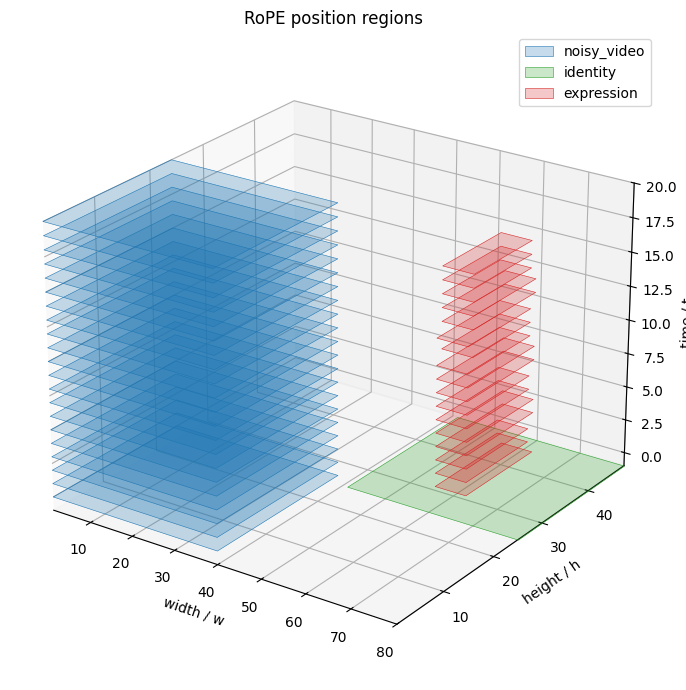

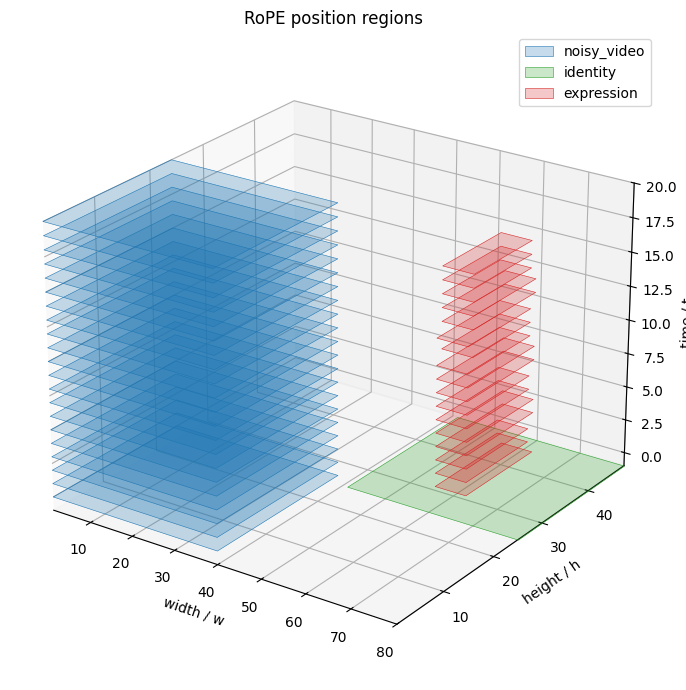

In [17]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

def frame_surfaces(coords, group):
    mask = coords["group"] == group
    ts = np.unique(coords["t"][mask])

    surfaces = []
    for t in ts:
        m = mask & (coords["t"] == t)
        if not np.any(m):
            continue

        w_min, w_max = coords["w"][m].min(), coords["w"][m].max()
        h_min, h_max = coords["h"][m].min(), coords["h"][m].max()

        surfaces.append([
            (w_min, h_min, t),
            (w_max, h_min, t),
            (w_max, h_max, t),
            (w_min, h_max, t),
        ])

    return surfaces

def plot_all_groups_smooth(coords):
    styles = {
        "noisy_video": ("tab:green", 0.25),
        "identity": ("#003366", 0.25),
        "expression": ("#00bcd4", 0.25),
    }

    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")

    for group, (color, alpha) in styles.items():
        surfaces = frame_surfaces(coords, group)
        poly = Poly3DCollection(
            surfaces,
            facecolors=color,
            edgecolors=color,
            linewidths=0.4,
            alpha=alpha,
            label=group,
        )
        ax.add_collection3d(poly)

    ax.set_title("RoPE position regions")
    ax.set_xlabel("width / w")
    ax.set_ylabel("height / h")
    ax.set_zlabel("time / t")

    ax.set_xlim(coords["w"].min(), coords["w"].max())
    ax.set_ylim(coords["h"].min(), coords["h"].max())
    ax.set_zlim(coords["t"].min(), coords["t"].max())

    ax.view_init(elev=24, azim=-55)
    ax.legend()
    plt.tight_layout()
    return fig

plot_all_groups_smooth(all_coords)

## Sanity checks

Ces checks verifient que les longueurs de frequences collent aux tokens, que les conditions sont hors de la zone noisy video, et que identity/expression utilisent le meme offset `h/w`.

In [ ]:
expected_condition_tokens = condition.identity_token_count + condition.expression_token_count
assert condition_freqs.shape[0] == expected_condition_tokens, (condition_freqs.shape[0], expected_condition_tokens)
assert main_freqs.shape[0] == main_token_count, (main_freqs.shape[0], main_token_count)

def bounds(coords, group):
    mask = coords["group"] == group
    return {
        "t": (coords["t"][mask].min(), coords["t"][mask].max()),
        "h": (coords["h"][mask].min(), coords["h"][mask].max()),
        "w": (coords["w"][mask].min(), coords["w"][mask].max()),
    }

video_b = bounds(all_coords, "noisy_video")
identity_b = bounds(all_coords, "identity")
expression_b = bounds(all_coords, "expression")

assert identity_b["t"] == (-1, -1), identity_b
assert expression_b["t"][0] >= 0, expression_b
assert identity_b["h"][0] > video_b["h"][1], (video_b, identity_b)
assert expression_b["h"][0] == identity_b["h"][0], (identity_b, expression_b)
assert identity_b["w"][0] > video_b["w"][1], (video_b, identity_b)
assert expression_b["w"][0] == identity_b["w"][0], (identity_b, expression_b)

print("OK")
print("video", video_b)
print("identity", identity_b)
print("expression", expression_b)